# 03 – Supervised Learning: Engagement Prediction Model

**Project:** Machine learning based instagram marketing statergy  
**Course:** MSDS 696 – Data Practicum II | Regis University

**This notebook covers:**
- Loading `clustered_data.csv` from the previous notebook
- Encoding categorical features (`hashtag`, `time_of_day`, `media_type`)
- Training a `RandomForestRegressor` to predict post engagement
- Evaluating model performance (R², MAE, RMSE)
- Building a `predict_engagement(hashtag, time_of_day, media_type)` function used by the RL agent
- Saving the trained model as `model.pkl`

**Input:** `clustered_data.csv`  
**Output:** `model.pkl`, `encoder_maps.pkl`  
**Note:** `media_type` (image / carousel / reel) is now a model feature, enabling the RL agent to recommend *what to post* in addition to *when to post*.

## 1. Setup – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
print("Libraries loaded.")

Libraries loaded.


## 2. Load Clustered Data

In [2]:
df = pd.read_csv("clustered_data.csv")

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head(5)

Loaded: 16613 rows x 11 columns
Columns: ['id', 'hashtag', 'media_type', 'timestamp', 'like_count', 'comments_count', 'engagement', 'hour', 'time_of_day', 'day_of_week', 'cluster']


,id,hashtag,media_type,timestamp,like_count,comments_count,engagement,hour,time_of_day,day_of_week,cluster
0,22915435894288827_9698230649,#AppleEvent2025,image,2025-08-15 15:00:00,449,10,459,15,afternoon,Friday,1
1,29191953052727066_6956945746,#AppleEvent2025,carousel,2025-09-21 09:00:00,371,9,380,9,morning,Sunday,0
2,72960122594310041_1245922070,#AppleEvent2025,reel,2025-10-04 15:00:00,444,17,461,15,afternoon,Saturday,1
3,05721201179386725_5701477640,#AppleEvent2025,carousel,2025-07-26 11:00:00,0,5,5,11,morning,Saturday,0
4,53220646887044715_1396570748,#AppleEvent2025,carousel,2025-09-02 04:00:00,836,21,857,4,night,Tuesday,1


## 3. Feature Engineering – Encoding Categorical Variables

The model needs numeric inputs. We use fixed label encoding (not sklearn's LabelEncoder)  
so the same mapping is reused consistently in the RL agent notebook.

**Categorical features encoded:** `hashtag`, `time_of_day`, `media_type`

In [3]:
# Fixed encoding maps — deterministic, same order used in RL notebook
HASHTAG_ENCODER = {
    "#AppleEvent2025": 0,
    "#MadeByGoogle"  : 1,
    "#GalaxyS25"     : 2,
    "#GalaxyS25Edge" : 3
}

TIME_ENCODER = {
    "morning"  : 0,
    "afternoon": 1,
    "evening"  : 2,
    "night"    : 3
}

MEDIA_TYPE_ENCODER = {
    "image"   : 0,
    "carousel": 1,
    "reel"    : 2
}

# Reverse maps (used by the RL agent to decode predictions)
HASHTAG_DECODER    = {v: k for k, v in HASHTAG_ENCODER.items()}
TIME_DECODER       = {v: k for k, v in TIME_ENCODER.items()}
MEDIA_TYPE_DECODER = {v: k for k, v in MEDIA_TYPE_ENCODER.items()}

# Apply encoding to dataframe
df["hashtag_encoded"]    = df["hashtag"].map(HASHTAG_ENCODER)
df["time_encoded"]       = df["time_of_day"].map(TIME_ENCODER)
df["media_type_encoded"] = df["media_type"].map(MEDIA_TYPE_ENCODER)

# Drop rows where media_type is unknown / unmapped
before = len(df)
df = df.dropna(subset=["hashtag_encoded", "time_encoded", "media_type_encoded"]).reset_index(drop=True)
print(f"Rows dropped due to unmapped values: {before - len(df)}")

print("\nEncoding applied.")
print(f"Hashtag map    : {HASHTAG_ENCODER}")
print(f"Time map       : {TIME_ENCODER}")
print(f"Media type map : {MEDIA_TYPE_ENCODER}")
print(f"\nAny NaN after encoding: {df[['hashtag_encoded','time_encoded','media_type_encoded']].isnull().any().any()}")

Rows dropped due to unmapped values: 0

Encoding applied.
Hashtag map    : {'#AppleEvent2025': 0, '#MadeByGoogle': 1, '#GalaxyS25': 2, '#GalaxyS25Edge': 3}
Time map       : {'morning': 0, 'afternoon': 1, 'evening': 2, 'night': 3}
Media type map : {'image': 0, 'carousel': 1, 'reel': 2}

Any NaN after encoding: False


## 4. Train / Test Split

**Features:** `hashtag_encoded`, `time_encoded`, `media_type_encoded`, `cluster`  
**Target:** `engagement`

In [4]:
FEATURE_COLS = ["hashtag_encoded", "time_encoded", "media_type_encoded", "cluster"]
TARGET_COL   = "engagement"

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"\nFeatures     : {FEATURE_COLS}")
print(f"Target       : {TARGET_COL}")

Training set : 13290 rows
Test set     : 3323 rows

Features     : ['hashtag_encoded', 'time_encoded', 'media_type_encoded', 'cluster']
Target       : engagement


## 5. Train RandomForestRegressor

In [5]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"\nModel: {model}")
print(f"Number of trees: {model.n_estimators}")

Model trained successfully.

Model: RandomForestRegressor(n_jobs=-1, random_state=42)
Number of trees: 100


## 6. Model Evaluation

In [6]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Cross-validation R² (5-fold) for a more robust estimate
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("=== Model Performance on Test Set ===")
print(f"  R²   : {r2:.4f}")
print(f"  MAE  : {mae:.2f}   (avg. engagement prediction error)")
print(f"  RMSE : {rmse:.2f}")
print(f"\n=== 5-Fold Cross-Validation R² ===")
print(f"  Scores : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")

=== Model Performance on Test Set ===
  R²   : 0.7308
  MAE  : 107.49   (avg. engagement prediction error)
  RMSE : 153.12

=== 5-Fold Cross-Validation R² ===
  Scores : [np.float64(0.5671), np.float64(0.7523), np.float64(0.7357), np.float64(0.7328), np.float64(0.7416)]
  Mean   : 0.7059
  Std    : 0.0697


## 7. Visualizations

### 7.1 – Actual vs Predicted Engagement

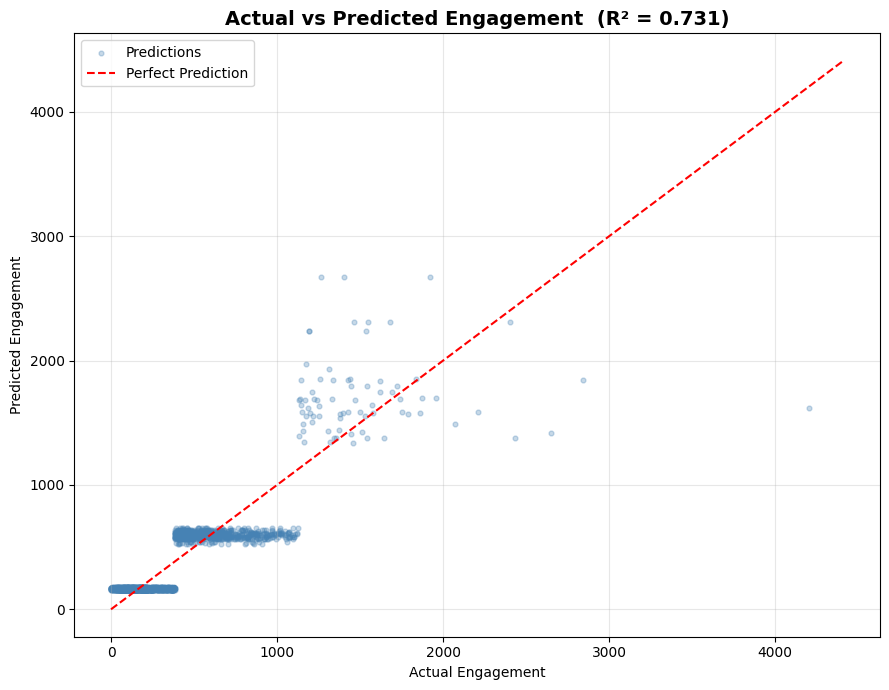

Saved: plot_09_actual_vs_predicted.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(y_test, y_pred, alpha=0.3, s=12, color="steelblue", label="Predictions")

# Perfect prediction line
lim = max(y_test.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_title(f"Actual vs Predicted Engagement  (R² = {r2:.3f})", fontsize=14, fontweight="bold")
ax.set_xlabel("Actual Engagement")
ax.set_ylabel("Predicted Engagement")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot_09_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_09_actual_vs_predicted.png")

### 7.2 – Feature Importance

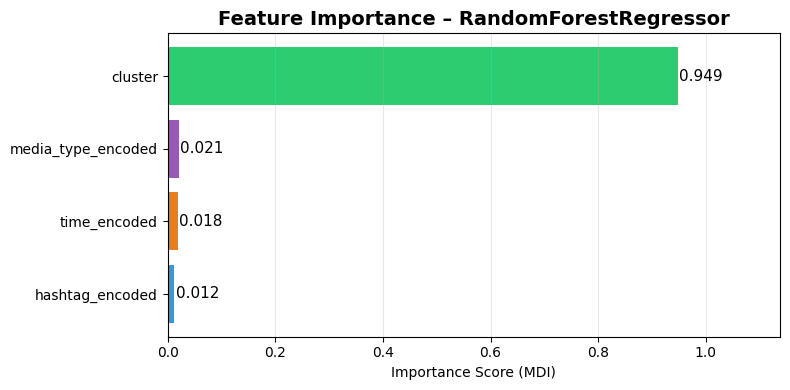

Saved: plot_10_feature_importance.png


In [8]:
importances = model.feature_importances_
feat_series = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

# One color per feature — 4 features now (hashtag, time, media_type, cluster)
FEAT_COLORS = ["#3498DB", "#E67E22", "#9B59B6", "#2ECC71"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(feat_series.index, feat_series.values,
               color=FEAT_COLORS[:len(feat_series)])

for bar, val in zip(bars, feat_series.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=11)

ax.set_title("Feature Importance – RandomForestRegressor", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score (MDI)")
ax.set_xlim(0, feat_series.max() * 1.2)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_10_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_10_feature_importance.png")

### 7.3 – Average Predicted Engagement by Hashtag × Time of Day

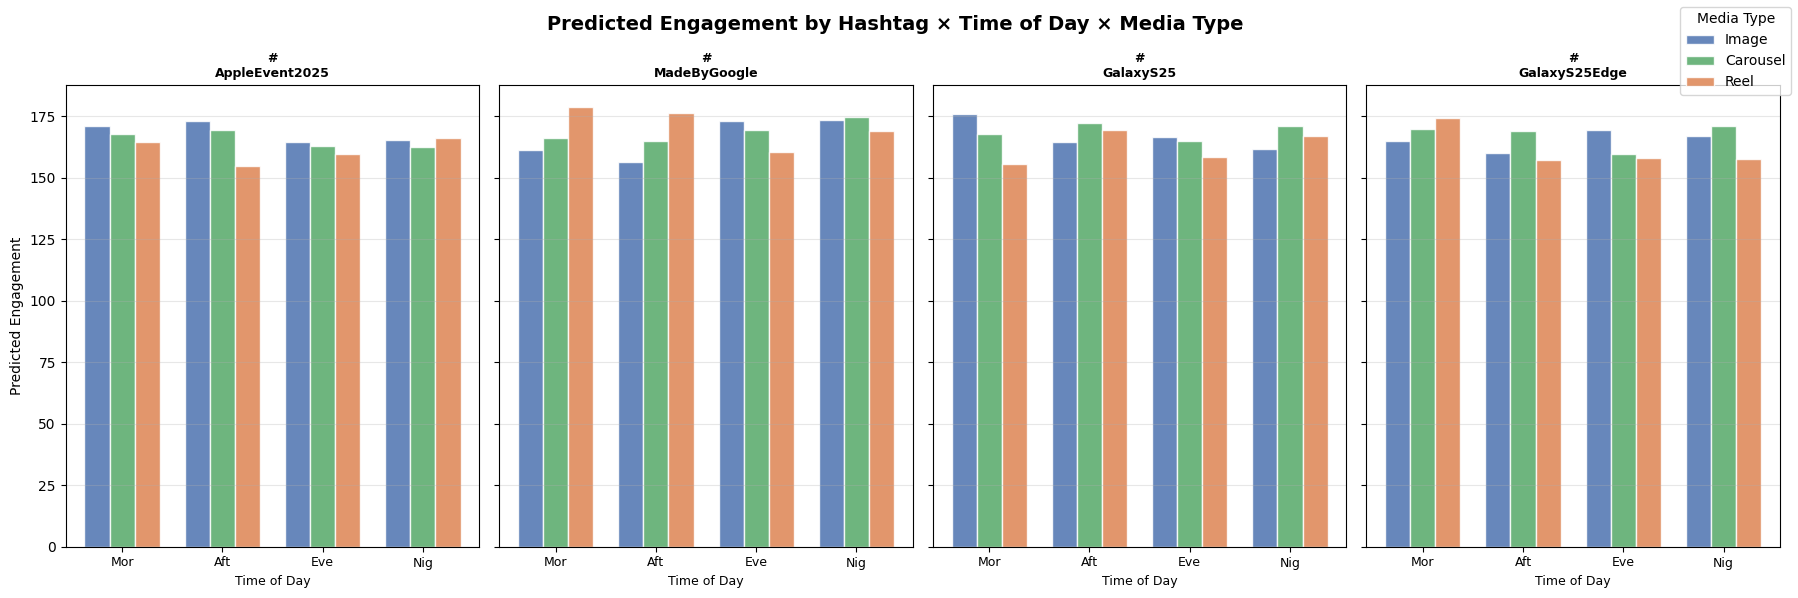

Saved: plot_11_engagement_by_time_hashtag_media.png

=== Top 10 Predicted Combinations (What + When to Post) ===
            hashtag media_type time_of_day  predicted_engagement
1     #MadeByGoogle       reel     morning            178.607673
2     #MadeByGoogle       reel   afternoon            176.389258
3        #GalaxyS25      image     morning            176.037713
4     #MadeByGoogle   carousel       night            174.565062
5    #GalaxyS25Edge       reel     morning            174.341395
6     #MadeByGoogle      image       night            173.503610
7     #MadeByGoogle      image     evening            173.223889
8   #AppleEvent2025      image   afternoon            173.090716
9        #GalaxyS25   carousel   afternoon            172.403093
10   #GalaxyS25Edge   carousel       night            170.980721


In [9]:
# Build a grid of all 48 hashtag × time × media_type combinations and predict engagement
hashtags    = list(HASHTAG_ENCODER.keys())
time_slots  = list(TIME_ENCODER.keys())
media_types = list(MEDIA_TYPE_ENCODER.keys())

rows = []
for h in hashtags:
    for t in time_slots:
        for m in media_types:
            h_enc = HASHTAG_ENCODER[h]
            t_enc = TIME_ENCODER[t]
            m_enc = MEDIA_TYPE_ENCODER[m]
            # Use the most common cluster for this hashtag+time+media_type combo
            mask = (
                (df["hashtag_encoded"]    == h_enc) &
                (df["time_encoded"]       == t_enc) &
                (df["media_type_encoded"] == m_enc)
            )
            cluster_mode = int(df.loc[mask, "cluster"].mode()[0]) if mask.any() else 0
            pred = model.predict([[h_enc, t_enc, m_enc, cluster_mode]])[0]
            rows.append({
                "hashtag"           : h,
                "time_of_day"       : t,
                "media_type"        : m,
                "predicted_engagement": pred
            })

grid_df = pd.DataFrame(rows)

# ── Grouped bar: best media type per hashtag per time slot ──
TIME_ORDER  = list(TIME_ENCODER.keys())
MEDIA_COLORS_MAP = {"image": "#4C72B0", "carousel": "#55A868", "reel": "#DD8452"}

fig, axes = plt.subplots(1, len(hashtags), figsize=(18, 6), sharey=True)
fig.suptitle("Predicted Engagement by Hashtag × Time of Day × Media Type",
             fontsize=14, fontweight="bold")

x = np.arange(len(TIME_ORDER))
bar_width = 0.25

for ax, h in zip(axes, hashtags):
    for i, m in enumerate(media_types):
        vals = [
            grid_df.loc[
                (grid_df["hashtag"] == h) &
                (grid_df["time_of_day"] == t) &
                (grid_df["media_type"] == m),
                "predicted_engagement"
            ].values[0]
            for t in TIME_ORDER
        ]
        ax.bar(x + i * bar_width, vals, bar_width,
               label=m.capitalize(), color=MEDIA_COLORS_MAP[m], alpha=0.85, edgecolor="white")

    ax.set_title(h.replace("#", "#\n"), fontsize=9, fontweight="bold")
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([t[:3].capitalize() for t in TIME_ORDER], fontsize=9)
    ax.set_xlabel("Time of Day", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Predicted Engagement")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Media Type", loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("plot_11_engagement_by_time_hashtag_media.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_11_engagement_by_time_hashtag_media.png")

# Print top 10 combinations
print("\n=== Top 10 Predicted Combinations (What + When to Post) ===")
top10 = grid_df.nlargest(10, "predicted_engagement")[
    ["hashtag", "media_type", "time_of_day", "predicted_engagement"]
].reset_index(drop=True)
top10.index += 1
print(top10.to_string())

## 8. `predict_engagement` Helper Function

This function will be called by the RL agent in Notebook 04 to compute rewards.

In [10]:
def predict_engagement(
    mdl,
    hashtag_enc: int,
    time_enc: int,
    media_type_enc: int,
    reference_df: pd.DataFrame
) -> float:
    """
    Predict engagement for a (hashtag, time_of_day, media_type) combination.

    Parameters
    ----------
    mdl            : trained RandomForestRegressor
    hashtag_enc    : integer-encoded hashtag       (0–3)
    time_enc       : integer-encoded time slot      (0–3)
    media_type_enc : integer-encoded media type     (0=image, 1=carousel, 2=reel)
    reference_df   : DataFrame used to look up the modal cluster for the combination

    Returns
    -------
    float : predicted engagement score
    """
    mask = (
        (reference_df["hashtag_encoded"]    == hashtag_enc) &
        (reference_df["time_encoded"]       == time_enc)    &
        (reference_df["media_type_encoded"] == media_type_enc)
    )
    cluster_mode = int(reference_df.loc[mask, "cluster"].mode()[0]) if mask.any() else 0
    return float(mdl.predict([[hashtag_enc, time_enc, media_type_enc, cluster_mode]])[0])


# Quick sanity check — all three dimensions
sample = predict_engagement(model, 0, 1, 2, df)   # #AppleEvent2025, afternoon, reel
print(f"Sample prediction (#AppleEvent2025, afternoon, reel) → {sample:.1f} engagement")

sample2 = predict_engagement(model, 2, 0, 1, df)  # #GalaxyS25, morning, carousel
print(f"Sample prediction (#GalaxyS25, morning, carousel)    → {sample2:.1f} engagement")

Sample prediction (#AppleEvent2025, afternoon, reel) → 154.8 engagement
Sample prediction (#GalaxyS25, morning, carousel)    → 167.8 engagement


## 9. Save Model & Encoder Maps

In [11]:
import pickle

# Save the trained model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save encoder / decoder maps so Notebook 04 uses the exact same mapping
encoder_maps = {
    "HASHTAG_ENCODER"    : HASHTAG_ENCODER,
    "TIME_ENCODER"       : TIME_ENCODER,
    "MEDIA_TYPE_ENCODER" : MEDIA_TYPE_ENCODER,
    "HASHTAG_DECODER"    : HASHTAG_DECODER,
    "TIME_DECODER"       : TIME_DECODER,
    "MEDIA_TYPE_DECODER" : MEDIA_TYPE_DECODER,
}
with open("encoder_maps.pkl", "wb") as f:
    pickle.dump(encoder_maps, f)

print("Saved: model.pkl")
print("Saved: encoder_maps.pkl")
print("\nEncoder maps saved:")
for k in encoder_maps:
    print(f"  - {k}")
print("\nNotebook 03 complete. Outputs ready for Notebook 04 (RL Agent).")

Saved: model.pkl
Saved: encoder_maps.pkl

Encoder maps saved:
  - HASHTAG_ENCODER
  - TIME_ENCODER
  - MEDIA_TYPE_ENCODER
  - HASHTAG_DECODER
  - TIME_DECODER
  - MEDIA_TYPE_DECODER

Notebook 03 complete. Outputs ready for Notebook 04 (RL Agent).


## 10. Instagram Engagement vs Stock Market Performance

> **Research Question:** Does daily Instagram engagement around a brand's hashtag correlate with that brand's stock price movement?

### Brand → Stock Ticker Mapping

| Instagram Hashtag(s) | Brand | Stock Ticker |
|---|---|---|
| `#AppleEvent2025` | Apple | `AAPL` |
| `#MadeByGoogle` | Google | `GOOGL` |
| `#GalaxyS25`, `#GalaxyS25Edge` | Samsung | `005930.KS` |

Stock data source: `stock_data.csv` (covers 2024-11-25 → 2025-12-30, matching the Instagram date range).

In [12]:
from scipy.stats import pearsonr

# ── 1. Load stock data (one folder up from instagram_rl_strategy/) ──────────
stock = pd.read_csv("../stock_data.csv")
stock["date"] = pd.to_datetime(stock["Date_"]).dt.date.astype(str)

# Keep only Close prices
close_cols = {"Close_AAPL": "AAPL", "Close_GOOGL": "GOOGL", "Close_005930.KS": "Samsung"}
stock = stock[["date"] + list(close_cols.keys())].rename(columns=close_cols)
stock = stock.dropna(subset=["AAPL", "GOOGL"])   # drop US-market holidays (Samsung may have different calendar)

print(f"Stock data   : {stock.shape[0]} trading days")
print(f"Date range   : {stock['date'].min()}  →  {stock['date'].max()}")

# ── 2. Build daily Instagram engagement per brand ────────────────────────────
df["date"] = pd.to_datetime(df["timestamp"], format="mixed").dt.date.astype(str)

# Galaxy S25 + S25 Edge → Samsung
HASHTAG_TO_BRAND = {
    "#AppleEvent2025" : "AAPL",
    "#MadeByGoogle"   : "GOOGL",
    "#GalaxyS25"      : "Samsung",
    "#GalaxyS25Edge"  : "Samsung",
}
df["brand"] = df["hashtag"].map(HASHTAG_TO_BRAND)
daily_eng = (
    df.groupby(["date", "brand"])["engagement"]
    .sum()
    .reset_index()
    .rename(columns={"engagement": "daily_engagement"})
)

print(f"\nInstagram daily rows : {daily_eng.shape[0]}")
print(daily_eng.head(6).to_string(index=False))

Stock data   : 274 trading days
Date range   : 2024-11-25  →  2025-12-30

Instagram daily rows : 360
      date   brand  daily_engagement
2024-11-24 Samsung             16137
2024-11-25 Samsung             21261
2024-11-26 Samsung             17237
2024-11-27 Samsung             16522
2024-11-28 Samsung             11884
2024-11-29 Samsung             18249


### 10.1 – Dual-Axis Time Series: Engagement vs Stock Close Price (per Brand)

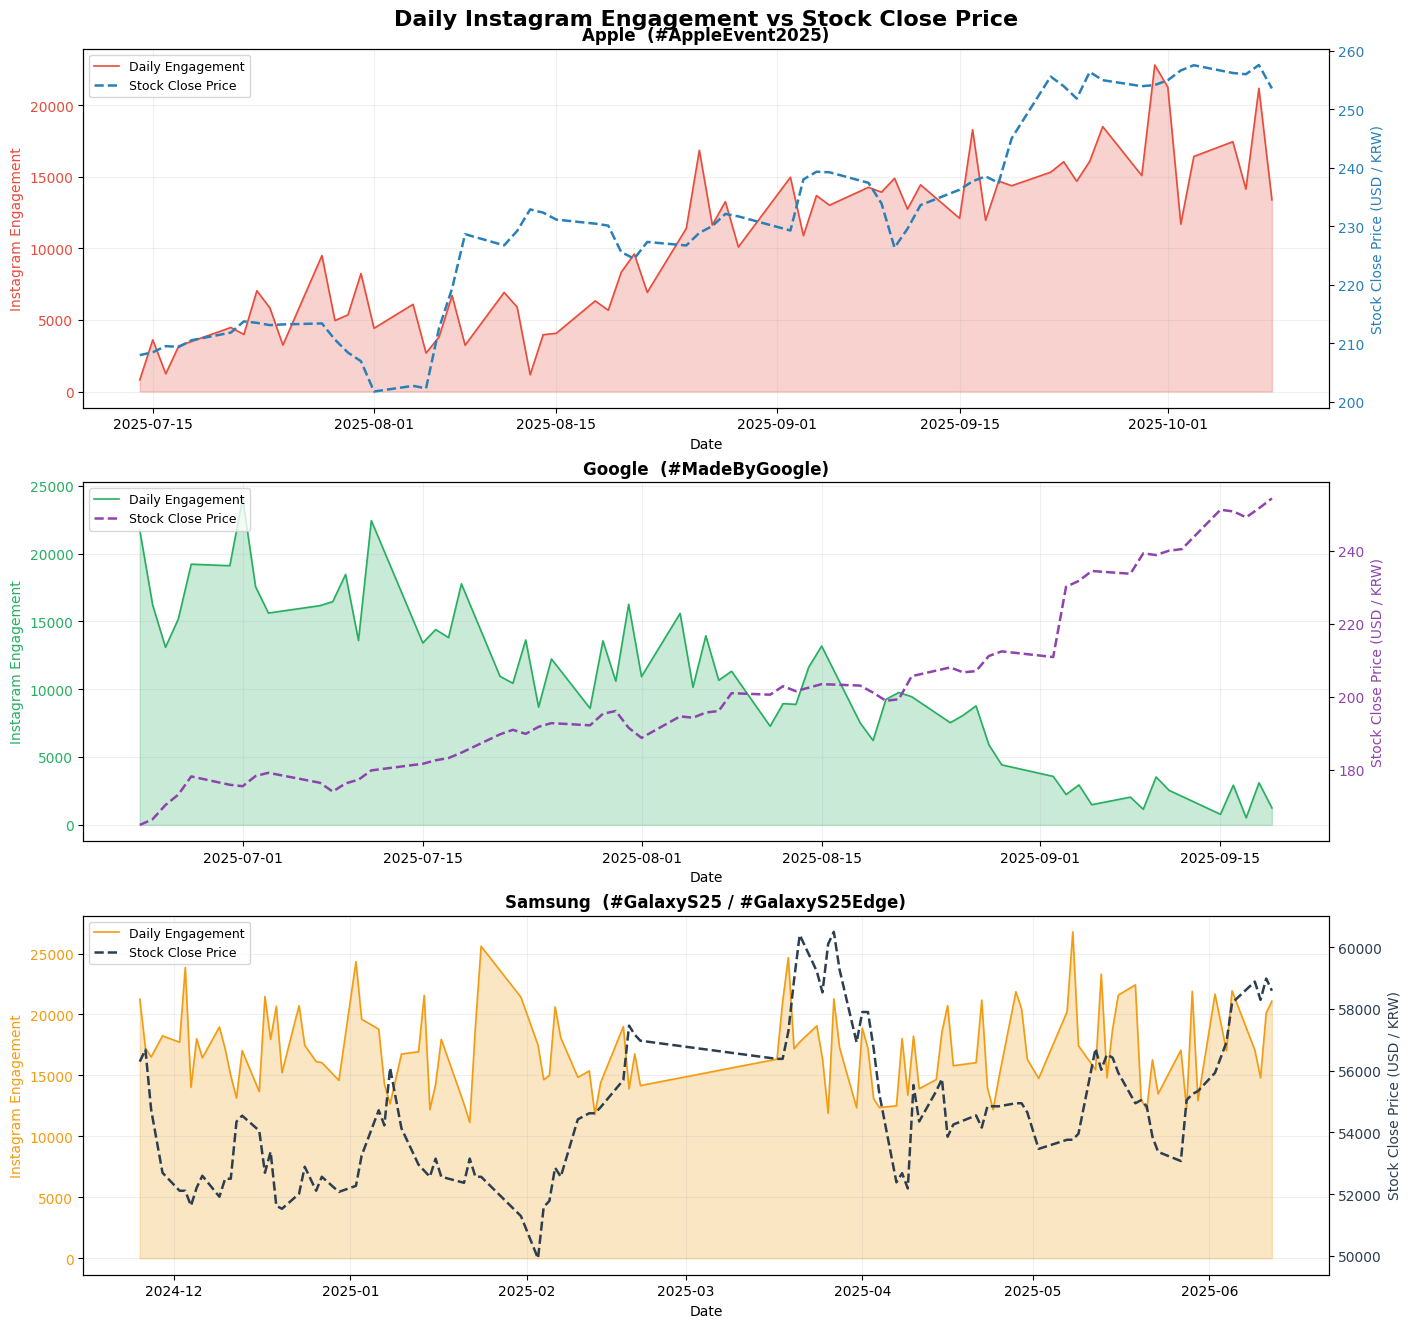

Saved: plot_12_engagement_vs_stock.png


In [13]:
BRANDS = [
    ("AAPL",    "Apple",   "#AppleEvent2025",  "#E74C3C", "#2980B9"),
    ("GOOGL",   "Google",  "#MadeByGoogle",    "#27AE60", "#8E44AD"),
    ("Samsung", "Samsung", "#GalaxyS25 / #GalaxyS25Edge", "#F39C12", "#2C3E50"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 13), constrained_layout=True)
fig.suptitle("Daily Instagram Engagement vs Stock Close Price",
             fontsize=16, fontweight="bold", y=1.01)

for ax, (ticker, brand_name, hashtag_label, eng_color, stock_color) in zip(axes, BRANDS):
    brand_eng = daily_eng[daily_eng["brand"] == ticker].copy()
    brand_eng["date"] = pd.to_datetime(brand_eng["date"])

    stock_col = ticker   # column name matches ticker
    brand_stock = stock[["date", stock_col]].copy()
    brand_stock["date"] = pd.to_datetime(brand_stock["date"])
    brand_stock = brand_stock.dropna(subset=[stock_col])

    # Merge on date (inner join — only trading days with Instagram data)
    merged = pd.merge(brand_eng, brand_stock, on="date", how="inner").sort_values("date")

    if merged.empty:
        ax.set_title(f"{brand_name} — no overlapping dates")
        continue

    ax2 = ax.twinx()

    ax.fill_between(merged["date"], merged["daily_engagement"],
                    alpha=0.25, color=eng_color)
    ax.plot(merged["date"], merged["daily_engagement"],
            color=eng_color, linewidth=1.2, label="Daily Engagement")
    ax.set_ylabel("Instagram Engagement", color=eng_color, fontsize=10)
    ax.tick_params(axis="y", labelcolor=eng_color)

    ax2.plot(merged["date"], merged[stock_col],
             color=stock_color, linewidth=1.8, linestyle="--", label="Stock Close Price")
    ax2.set_ylabel("Stock Close Price (USD / KRW)", color=stock_color, fontsize=10)
    ax2.tick_params(axis="y", labelcolor=stock_color)

    ax.set_title(f"{brand_name}  ({hashtag_label})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Date")
    ax.grid(alpha=0.2)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.savefig("plot_12_engagement_vs_stock.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_12_engagement_vs_stock.png")

### 10.2 – Pearson Correlation: Engagement vs Stock Price

In [14]:
corr_results = []

for ticker, brand_name, _, _, _ in BRANDS:
    brand_eng = daily_eng[daily_eng["brand"] == ticker].copy()
    brand_eng["date"] = pd.to_datetime(brand_eng["date"])

    brand_stock = stock[["date", ticker]].copy()
    brand_stock["date"] = pd.to_datetime(brand_stock["date"])
    brand_stock = brand_stock.dropna(subset=[ticker])

    merged = pd.merge(brand_eng, brand_stock, on="date", how="inner")

    if len(merged) < 5:
        corr_results.append({
            "Brand": brand_name,
            "N (overlap days)": len(merged),
            "Pearson r": None,
            "p-value": None,
            "Interpretation": "Insufficient data",
        })
        continue

    r, p = pearsonr(merged["daily_engagement"], merged[ticker])
    if abs(r) >= 0.7:
        interp = "Strong"
    elif abs(r) >= 0.4:
        interp = "Moderate"
    else:
        interp = "Weak"
    direction = "positive" if r > 0 else "negative"

    corr_results.append({
        "Brand"            : brand_name,
        "N (overlap days)" : len(merged),
        "Pearson r"        : round(r, 4),
        "p-value"          : round(p, 4),
        "Interpretation"   : f"{interp} {direction}",
    })

corr_df = pd.DataFrame(corr_results)
print("=== Pearson Correlation: Instagram Engagement vs Stock Close Price ===\n")
print(corr_df.to_string(index=False))

=== Pearson Correlation: Instagram Engagement vs Stock Close Price ===

  Brand  N (overlap days)  Pearson r  p-value  Interpretation
  Apple                63     0.7997   0.0000 Strong positive
 Google                63    -0.8962   0.0000 Strong negative
Samsung               111     0.0149   0.8768   Weak positive


### 10.3 – Correlation Bar Chart

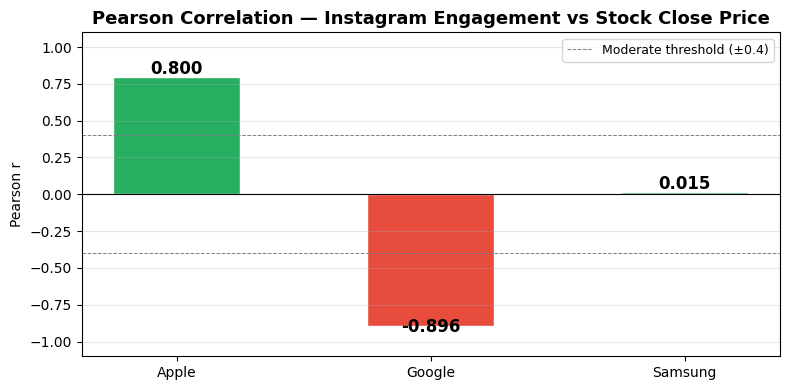

Saved: plot_13_correlation_bar.png


In [15]:
valid = corr_df.dropna(subset=["Pearson r"])
colors = ["#27AE60" if r >= 0 else "#E74C3C" for r in valid["Pearson r"]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(valid["Brand"], valid["Pearson r"], color=colors, edgecolor="white", width=0.5)

for bar, val in zip(bars, valid["Pearson r"]):
    ypos = val + 0.02 if val >= 0 else val - 0.04
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.4,  color="gray", linewidth=0.7, linestyle="--", label="Moderate threshold (±0.4)")
ax.axhline(-0.4, color="gray", linewidth=0.7, linestyle="--")
ax.set_title("Pearson Correlation — Instagram Engagement vs Stock Close Price",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Pearson r")
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_13_correlation_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_13_correlation_bar.png")

### 10.4 – Scatter: Engagement vs Stock Price (per Brand)

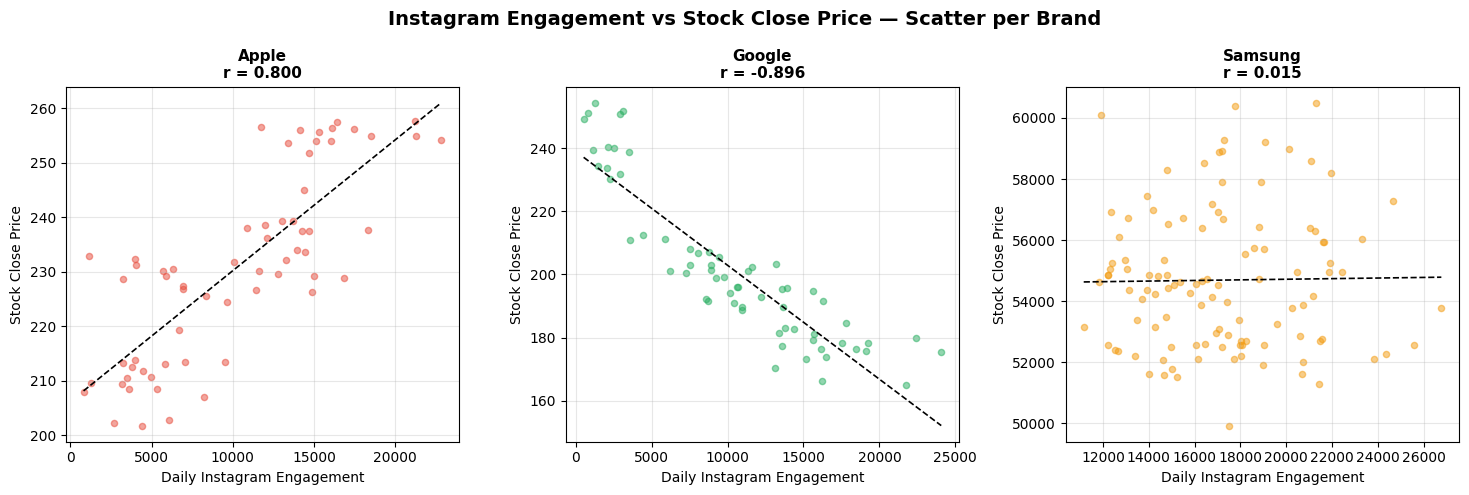

Saved: plot_14_scatter_engagement_vs_stock.png


In [16]:
SCATTER_COLORS = {"AAPL": "#E74C3C", "GOOGL": "#27AE60", "Samsung": "#F39C12"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Instagram Engagement vs Stock Close Price — Scatter per Brand",
             fontsize=14, fontweight="bold")

for ax, (ticker, brand_name, _, _, _) in zip(axes, BRANDS):
    brand_eng = daily_eng[daily_eng["brand"] == ticker].copy()
    brand_eng["date"] = pd.to_datetime(brand_eng["date"])
    brand_stock = stock[["date", ticker]].copy()
    brand_stock["date"] = pd.to_datetime(brand_stock["date"])
    brand_stock = brand_stock.dropna(subset=[ticker])
    merged = pd.merge(brand_eng, brand_stock, on="date", how="inner")

    if merged.empty:
        ax.set_title(f"{brand_name} — no data")
        continue

    r_row = corr_df[corr_df["Brand"] == brand_name]
    r_val = r_row["Pearson r"].values[0] if not r_row.empty else None

    ax.scatter(merged["daily_engagement"], merged[ticker],
               alpha=0.5, s=20, color=SCATTER_COLORS[ticker])

    # Trend line
    z = np.polyfit(merged["daily_engagement"], merged[ticker], 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(merged["daily_engagement"].min(), merged["daily_engagement"].max(), 100)
    ax.plot(x_line, p_fit(x_line), "k--", linewidth=1.2)

    title = f"{brand_name}"
    if r_val is not None:
        title += f"\nr = {r_val:.3f}"
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Daily Instagram Engagement")
    ax.set_ylabel("Stock Close Price")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot_14_scatter_engagement_vs_stock.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_14_scatter_engagement_vs_stock.png")

### 10.5 – Key Insights

**Interpretation guide:**
- **r > 0.4** → Higher Instagram engagement tends to coincide with higher stock price (positive relationship)
- **r < −0.4** → Higher engagement coincides with lower stock price (possible negative sentiment driver)
- **|r| < 0.4** → Weak or no linear relationship between social engagement and stock price

> **Note:** Correlation does not imply causation. Instagram engagement reflects public interest and sentiment around a brand's product launch or campaign, while stock price is driven by a much broader set of market factors. However, consistent positive correlation would suggest social media signals could serve as a **leading or coincident indicator** of investor sentiment.